One-Hot Encoding

In [2]:
import numpy as np
# Step 1: Convert Text to Lower case
text = "My Name is AKilesh"
text_lower = text.lower()
# Step 2: Tokenize the text
tokens = text_lower.split()
# Step 3: Get unique words
unique_words = set (tokens)
# Step 4: Sort the word List
sorted_words = sorted(unique_words)
# Step 5: Get the integer/position of the words
word_to_index = {word: index for index, word in enumerate(sorted_words)}
# Step 6 and 7: Create one-hot vectors and matrix
one_hot_matrix = np.zeros((len(tokens), len(unique_words)))
for i, token in enumerate(tokens):
    word_index = word_to_index[token]
    one_hot_matrix[i, word_index] = 1
# Display the results
print("Original Text:", text)
print("One-Hot Matrix:")
print(one_hot_matrix)

Original Text: My Name is AKilesh
One-Hot Matrix:
[[0. 0. 1. 0.]
 [0. 0. 0. 1.]
 [0. 1. 0. 0.]
 [1. 0. 0. 0.]]


Bag of Words

In [3]:
from sklearn.feature_extraction.text import CountVectorizer
# Example Sentences
sentence1 = "My Name is AKilesh"
sentence2 = "I am a student at AVV chennai"
# Step 1: Convert to Lowercase
sentence1 = sentence1.lower()
sentence2 = sentence2.lower()
#
#
# Step 2: Remove special characters and stopwords (optional)
# In this example, we'll skip this step for simplicity.
# Step 3: Create a list of sentences
corpus = [sentence1, sentence2]
# Step 4: Use CountVectorizer to create Bag of Words model
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(corpus)
# Display the vocabulary and the Bag of Words matrix
print("Vocabulary:", vectorizer.get_feature_names_out())
print("Bag of Words Matrix:")
print(X.toarray())

Vocabulary: ['akilesh' 'am' 'at' 'avv' 'chennai' 'is' 'my' 'name' 'student']
Bag of Words Matrix:
[[1 0 0 0 0 1 1 1 0]
 [0 1 1 1 1 0 0 0 1]]


In [4]:
import pandas as pd
import numpy as nd
# Construct a small corpus
corpus = ['data science is one of the most important fields of science',
'this is one of the best data science courses',
'data scientists analyze data']
# Create a word set for the corpus
words_set = set()
for doc in corpus:
    words = doc.split() # Fixed: Changed from split('') to split() for proper word tokenization
    words_set = words_set.union(set(words))
print('Number of words in the corpus:', len(words_set))
print('The words in the corpus:\n', words_set)
# Computing Term Frequency (TF)
n_docs = len(corpus)
n_words_set = len(words_set)
df_tf = pd.DataFrame(np.zeros((n_docs, n_words_set)), columns=list(words_set))
# Compute Term Frequency (TF)
for i in range(n_docs):
    words = corpus[i].split(' ') # Words in the document
    for w in words:
        df_tf.loc[i, w] = df_tf.loc[i, w] + (1 / len(words)) # Fixed: Using .loc to avoid ChainedAssignmentError
print("Term Frequency (TF):")
print(df_tf)
# Computing Inverse Document Frequency (IDF)
print("\nInverse Document Frequency (IDF):")
idf = {}
for w in words_set: # Fixed: Corrected typo from words _set to words_set
    k = 0 # number of documents in the corpus that contain this word
    for i in range(n_docs):
        if w in corpus[i].split():
            k += 1
    idf[w] = np.log10(n_docs / k)
    print(f'{w:>15}: {idf[w]:>10}.') # Fixed: Removed unclosed parenthesis
# Putting it Together: Computing TF-IDF
df_tf_idf = df_tf.copy()
for w in words_set:
    for i in range(n_docs):
        df_tf_idf.loc[i, w] = df_tf.loc[i, w] * idf[w] # Fixed: Using .loc to avoid ChainedAssignmentError
print("\nTF-IDF:")
print(df_tf_idf)
# Removed: 'localhost:8888/notebooks/Downloads/NLP' was not valid Python code

Number of words in the corpus: 14
The words in the corpus:
 {'best', 'science', 'is', 'courses', 'the', 'analyze', 'scientists', 'this', 'important', 'fields', 'most', 'of', 'one', 'data'}
Term Frequency (TF):
       best   science        is   courses       the  analyze  scientists  \
0  0.000000  0.181818  0.090909  0.000000  0.090909     0.00        0.00   
1  0.111111  0.111111  0.111111  0.111111  0.111111     0.00        0.00   
2  0.000000  0.000000  0.000000  0.000000  0.000000     0.25        0.25   

       this  important    fields      most        of       one      data  
0  0.000000   0.090909  0.090909  0.090909  0.181818  0.090909  0.090909  
1  0.111111   0.000000  0.000000  0.000000  0.111111  0.111111  0.111111  
2  0.000000   0.000000  0.000000  0.000000  0.000000  0.000000  0.500000  

Inverse Document Frequency (IDF):
           best: 0.47712125471966244.
        science: 0.17609125905568124.
             is: 0.17609125905568124.
        courses: 0.47712125471966244

WORD2VEC

In [5]:
pip install gensim

In [6]:
import gensim
from gensim.models import KeyedVectors
import gensim.downloader as api
# DownLoad the pre-trained Word2Vec model from Google (takes some time)
# This downloads a large file, so be patient.
word2vec_model_path = api.load("word2vec-google-news-300", return_path=True)
# Load the Word2Vec model using gensim
word2vec_model = gensim.models.KeyedVectors.load_word2vec_format(word2vec_model_path, binary=True)
# Example: Get the word embedding for the word "king"
word_embedding = word2vec_model["king"]
# Print the dimensionality of the word embedding
print("Dimensionality of word embedding:", len(word_embedding))
# Example: Get the most similar words to "king"
similar_words = word2vec_model.most_similar("king")
print("Words most similar to 'king':", similar_words)
# Example: Calculate the similarity between two words
similarity_score = word2vec_model.similarity("king", "queen")
print("Similarity between 'king' and 'queen':", similarity_score)
# Example: Calculate the vector representing the combination of words "king" and "man" minus
result_vector = word2vec_model.most_similar(positive=["king", "man"], negative=["woman"], topn=1)
print("Vector representation of 'king- man + woman':", result_vector)

[==================================================] 100.0% 1662.8/1662.8MB downloaded
Dimensionality of word embedding: 300
Words most similar to 'king': [('kings', 0.7138045430183411), ('queen', 0.6510956883430481), ('monarch', 0.6413194537162781), ('crown_prince', 0.6204220056533813), ('prince', 0.6159993410110474), ('sultan', 0.5864824056625366), ('ruler', 0.5797567367553711), ('princes', 0.5646552443504333), ('Prince_Paras', 0.5432944297790527), ('throne', 0.5422105193138123)]
Similarity between 'king' and 'queen': 0.6510957
Vector representation of 'king- man + woman': [('kings', 0.6490575075149536)]


In [7]:
pip install spacy


In [8]:
!python -m spacy download en_core_web_md


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 15.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


GLOVE

In [9]:
import spacy
# Load the pre-trained GLoVe model
nlp = spacy.load("en_core_web_md")
# Test sentences
sentence1 = "I love natural language processing."
sentence2 = "GloVe is a powerful word embedding technique."
# Tokenize and get word embeddings for each sentence
doc1 = nlp(sentence1)
doc2 = nlp(sentence2) # Fixed: Changed n1p to nlp
# Print word embeddings for each word in the sentences
print("Word embeddings for sentence 1:")
for token in doc1:
    print(f"{token.text}: {token.vector}") # Fixed: IndentationError
print("\nWord embeddings for sentence 2:")
for token in doc2:
    print(f"{token.text}: {token.vector}") # Fixed: IndentationError

Word embeddings for sentence 1:
I: [-8.3712e-01 -4.0632e-01 -2.4202e-01 -3.7719e-01  5.5611e-03  2.9415e-01
 -2.1647e-01 -5.5052e-01 -8.1881e-02  1.5943e+00 -1.6071e-01  3.6091e-02
  2.3530e-01  7.5097e-02 -7.8328e-04 -1.1717e-01  1.5957e-01  2.6054e-01
 -1.3377e-01 -1.6710e-01  6.2175e-01  3.7112e-01  2.1664e-01 -2.3209e-01
 -8.2718e-02 -4.8991e-01 -2.6890e-01 -2.8994e-01  3.8026e-01 -1.7523e-01
  1.2028e-01  4.9040e-01 -1.7865e-01  1.2088e-01 -7.1101e-02  1.4119e-02
  1.4036e-01  8.7899e-02 -2.0833e-01  7.2154e-01 -3.2725e-01 -3.2122e-02
 -2.6132e-01  2.5442e-01  2.4288e-01 -1.5638e-01  3.1056e-01  3.6157e-01
 -5.4107e-01  4.2562e-01  5.0322e-02  3.1541e-01 -1.7380e-01  1.5163e-01
 -2.8188e-01  1.6727e-01  5.2491e-03 -1.8264e-01  3.1250e-01 -3.9406e-01
 -2.2052e-01  1.6621e-01 -2.4805e-01  1.3944e-01  3.9975e-01 -2.6014e-01
 -1.0253e-01  3.4850e-02 -1.0421e-01 -1.6384e-01 -1.4500e-02  1.3267e-01
  5.5815e-01 -1.5814e-01 -6.0617e-01  3.1015e-01 -9.9910e-02 -1.2486e-01
 -1.5990e-01  6.

In [10]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np # Changed ud to np for consistency and correctness

# Define a list of strings as your sample text
x = ['text', 'the', 'leader', 'prime', 'natural', 'language']

# Create the tokenizer
tokenizer = Tokenizer()
tokenizer.fit_on_texts(x)

# Number of unique words in the dictionary
print("Number of unique words in the dictionary =", len(tokenizer.word_index))
print("Dictionary is =", tokenizer.word_index)

# Function to create an embedding matrix for the vocabulary
def embedding_for_vocab(filepath, word_index, embedding_dim):
    vocab_size = len(word_index) + 1  # Corrected indentation
    # Adding again 1 because of reserved 0 index
    embedding_matrix_vocab = np.zeros((vocab_size, embedding_dim))
    try:
        with open(filepath, encoding="utf8") as f:
            for line in f:
                word, *vector = line.split()
                if word in word_index: # Corrected 'word index' to 'word_index'
                    idx = word_index[word]
                    # Ensure the vector has enough elements before slicing
                    if len(vector) >= embedding_dim:
                        embedding_matrix_vocab[idx] = np.array(vector, dtype=np.float32)[:embedding_dim] # Corrected slicing and variable
                    else:
                        # Handle cases where vector is too short (e.g., fill with zeros or skip)
                        print(f"Warning: Vector for '{word}' is too short. Skipping or padding with zeros.")

    except FileNotFoundError:
        print(f"Error: GloVe file '{filepath}' not found. Please ensure it's in the correct directory.")
        # Return an empty matrix or handle the error as appropriate for your application
        return np.zeros((vocab_size, embedding_dim))

    return embedding_matrix_vocab

# Define the embedding dimension
embedding_dim = 100

# Generate the embedding matrix for the given GloVe file
# Note: This will likely fail unless 'glove.6B.100d.txt' is downloaded and in the correct path
embedding_matrix_vocab = embedding_for_vocab('glove.6B.100d.txt', tokenizer.word_index, embedding_dim) # Completed function call

# Print the dense vector for the first word in the vocabulary
# This assumes the embedding matrix was successfully created and populated
if embedding_matrix_vocab.shape[0] > 1:
    first_word_in_vocab = list(tokenizer.word_index.keys())[0]
    first_word_id = tokenizer.word_index[first_word_in_vocab]
    print(f"\nDense vector for '{first_word_in_vocab}':\n{embedding_matrix_vocab[first_word_id]}")
else:
    print("Embedding matrix is empty or not properly initialized.")


Number of unique words in the dictionary = 6
Dictionary is = {'text': 1, 'the': 2, 'leader': 3, 'prime': 4, 'natural': 5, 'language': 6}
Error: GloVe file 'glove.6B.100d.txt' not found. Please ensure it's in the correct directory.

Dense vector for 'text':
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0.]


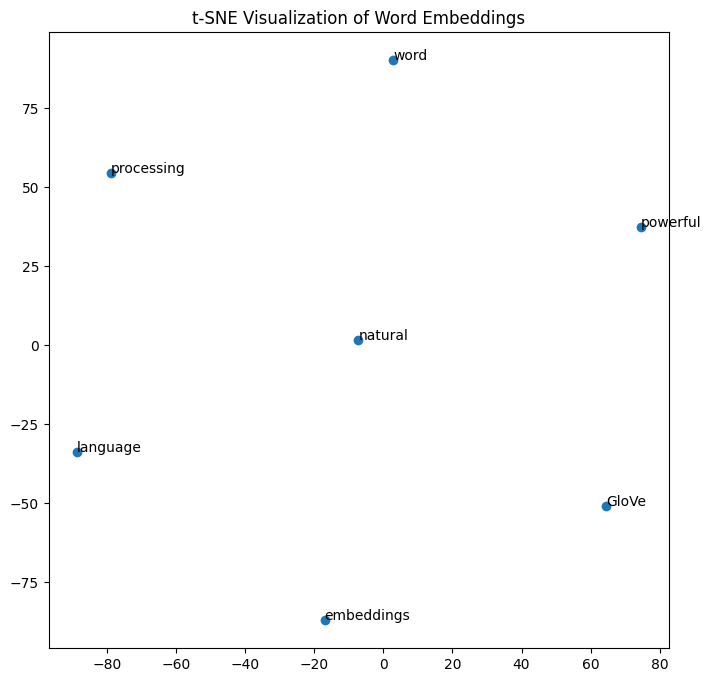

In [11]:
import spacy
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import numpy as np # Changed 'up' to 'np'
# Load the pre-trained GloVe model
nlp = spacy.load("en_core_web_md")
# List of words for visualization
words_to_visualize = ["natural", "language", "processing", "GloVe", "powerful", "word", "embeddings"]
# Get word embeddings for the selected words
word_vectors = [nlp(word).vector for word in words_to_visualize]
# Convert word_vectors to a NumPy array
word_vectors_array = np.array(word_vectors)
# Ensure perplexity is less than the number of samples
perplexity = min(30, len(word_vectors_array) - 1)
# Apply t-SNE to reduce dimensionality to 2D
tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42)
word_vectors_2d = tsne.fit_transform(word_vectors_array)
# Plot the words in 2D space
plt.figure(figsize=(8, 8))
plt.scatter(word_vectors_2d[:, 0], word_vectors_2d[:, 1])
# Annotate each point with the corresponding word
for i, word in enumerate(words_to_visualize):
    plt.annotate(word, (word_vectors_2d[i, 0], word_vectors_2d[i, 1])) # Fixed indentation
plt.title("t-SNE Visualization of Word Embeddings")
plt.show()

FAST TEXT

In [12]:
!pip install gensim
import nltk
from nltk.tokenize import word_tokenize
from gensim.models import FastText


# Download the 'punkt_tab' resource if not already downloaded
# This is necessary for word_tokenize to function correctly
try:
    nltk.data.find('tokenizers/punkt_tab')
except LookupError:
    nltk.download('punkt_tab')

# Dummy sentences
sentences = [
    "This is a sample sentence for FastText.",
    "FastText is a powerful word embedding model.",
    "We can train FastText on custom sentences too.",
    "Creating a simple example for demonstration.",
    "Let's check the similarity of some words."
]
# Tokenize the sentences
tokenized_sentences = [word_tokenize(sentence.lower()) for sentence in sentences]
# Train FastText model
model = FastText(
    sentences=tokenized_sentences,
    vector_size=128,
    window=5,
    min_count=1, # Adjust min_count as needed
    workers=4,
    epochs=10,
    sg=1,
    seed=42
)
# Save the trained model
model.save('dummy_fasttext_model')
# Access the word vectors
ftext = model.wv
# Check the number of unique words in the model
print("Number of unique words:", len(ftext.index_to_key))
# Check the vector size
print("Vector size:", ftext.vector_size)
# Get the vector for a specific word
word_vector = ftext["fasttext"]
print("Vector for 'fasttext':", word_vector)
# Find similar words
similar_words_mantap = ftext.similar_by_word("mantap", topn=5)
print("Similar words to 'mantap':", similar_words_mantap)
similar_words_bagus = ftext.similar_by_word("bagus", topn=5)
print("Similar words to 'bagus':", similar_words_bagus)


Number of unique words: 31
Vector size: 128
Vector for 'fasttext': [-5.51286794e-04  4.71519510e-04  1.40971912e-04  2.25756690e-03
  4.95882647e-04  5.73452096e-04 -5.66022471e-04 -7.51891115e-04
  7.35156762e-04 -9.59720521e-04  2.36583335e-04  1.08922104e-04
 -2.16032015e-04 -9.02636210e-04  8.23095674e-04  1.23100157e-03
 -1.52132707e-03  1.67099410e-03 -1.51669316e-03  2.14113868e-04
  2.46162497e-04 -1.23399997e-03  1.74106914e-04 -5.27375552e-04
  1.24393078e-03 -4.13229573e-04 -9.32499010e-04 -1.73430971e-03
  1.24169965e-05 -9.87429594e-05 -7.39470488e-05 -7.31765816e-04
  8.21911206e-04  8.13115446e-04  5.54838276e-04 -1.68513355e-03
  3.78581259e-04 -3.27800633e-04  1.74142746e-03  4.84747201e-04
  1.84382414e-04 -1.04627230e-04 -7.13720685e-04 -4.84464486e-04
 -8.27850308e-04  3.63124476e-04  1.26989296e-04 -1.50212087e-04
  1.57256902e-04  1.34926639e-04  6.92375295e-04 -1.41455163e-03
 -2.15040112e-04 -1.11658883e-03  4.58740309e-04  1.05737697e-03
 -5.11300459e-04 -1.823